# Minimal Example: Sparse-Observation Forward Simulation + GP Initial-Condition Inference

A trimmed-down version of `pde_inference_setup_exponax_ks.ipynb`, keeping only the two
patterns needed for this pairing:

1. Building a `dynestyx.DynamicalModel` whose observation operator is a genuinely sparse
   matrix (`jax.experimental.sparse.BCOO`), and running a forward simulation with it.
2. Treating the equation's initial condition as an unknown, Gaussian-process-distributed
   latent, and recovering it from noisy observations with NUTS.

See the full notebook for the exploratory detours this one skips: dense-vs-sparse $H$
comparisons, inferring the equation's $\lambda$ parameter, `RegularGridInterpolator`, and
EnKF sanity checks against a naive baseline.


In [1]:
import jax
jax.config.update("jax_enable_x64", True)


In [2]:
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax.experimental import sparse as jax_sparse
from numpyro.infer import MCMC, NUTS, init_to_value

import exponax as ex

import dynestyx as dsx
from dynestyx import DynamicalModel, Filter, LinearGaussianObservation
from dynestyx.observation import GridInterpolator
from dynestyx.inference.configs.filter import EnKFConfig


## The equation and its (fixed, known) dynamics

Conservative Kuramoto-Sivashinsky, as in the full notebook: a discrete-time transition of
`n_substeps` fixed ETDRK2 steps, wrapped as a bare `sample()`/`shape()` object (no
`log_prob` needed -- `EnKFConfig` only ever calls `.sample(key)` on it).


In [3]:
num_points = 64       # spectral resolution
domain_extent = 60.0   # periodic domain length
dt_ks = 0.5             # Exponax's own internal step size
n_substeps = 2           # ETDRK2 steps per dynestyx transition

stepper = ex.stepper.KuramotoSivashinskyConservative(
    num_spatial_dims=1, domain_extent=domain_extent, num_points=num_points, dt=dt_ks
)

state_dim_ks = num_points
control_dim_ks = 0
x_grid = jnp.linspace(0, domain_extent, num_points, endpoint=False)


class KSSample(eqx.Module):
    """Bare sample()/shape() object required by EnKFConfig -- no log_prob needed."""

    loc: jax.Array
    noise_std: float = eqx.field(static=True)

    def sample(self, key):
        return self.loc + self.noise_std * jr.normal(key, self.loc.shape)

    def shape(self):
        return self.loc.shape


class KSTransition(eqx.Module):
    """Discrete-time state_evolution: n_substeps fixed ETDRK2 steps of size dt_ks."""

    n_substeps: int = eqx.field(static=True)
    process_noise_std: float = eqx.field(static=True)

    def __call__(self, x, u, t_now, t_next):
        v = x.reshape(1, num_points)
        for _ in range(self.n_substeps):
            v = stepper(v)
        return KSSample(loc=v.reshape(num_points), noise_std=self.process_noise_std)


state_evolution = KSTransition(n_substeps=n_substeps, process_noise_std=1e-3)


## A sparse observation model

We observe $u$ at points placed anywhere in the domain (not aligned to the grid).
`dynestyx.observation.GridInterpolator` already builds exactly this kind of observation
operator -- piecewise-linear (or nearest-neighbor) interpolation on a regular grid, with
periodic boundary handling built in -- so there's no need to hand-roll an interpolator and
recover its matrix via `jax.jacobian` (see `grid_interpolator_examples.ipynb` for a fuller
tour). Each row of $H$ has only 2 nonzero entries (`method="linear"` in 1D) out of
`state_dim_ks = 64`, so we use `GridInterpolator.as_sparse()` -- a
`jax.experimental.sparse.BCOO` array -- directly as `LinearGaussianObservation.H`;
`EnKFConfig`, the filter used throughout this notebook, applies a sparse `H` directly.


In [4]:
n_obs = 32
x_obs = jr.uniform(jr.PRNGKey(42), (n_obs,), maxval=domain_extent)

interp = GridInterpolator((x_grid,), x_obs[:, None], method="linear", boundary="periodic")
H_sparse = interp.as_sparse()
print("H_sparse nse (stored nonzeros):", H_sparse.nse, " out of", n_obs * state_dim_ks, "dense entries")

observation_model = LinearGaussianObservation(H=H_sparse, R=0.02**2 * jnp.eye(n_obs))


H_sparse nse (stored nonzeros): 64  out of 2048 dense entries


## A Gaussian process prior over the initial condition

A GP prior over our finite grid is exactly a multivariate normal whose covariance is a
kernel matrix; `numpyro` needs no dedicated GP class for this (see the full notebook for
the derivation and the periodic-kernel formula). We build the kernel matrix $K$, its
Cholesky factor $L$, and use the non-centered parameterization $u_0 = \mu + Lz$ with
$z \sim \mathcal{N}(0, I)$.


In [5]:
def periodic_kernel(x1, x2, variance, lengthscale):
    d = jnp.abs(x1[:, None] - x2[None, :])
    d = jnp.minimum(d, domain_extent - d)  # periodic (wraparound) distance
    return variance * jnp.exp(-2.0 * jnp.sin(jnp.pi * d / domain_extent) ** 2 / lengthscale**2)


gp_variance = 0.3
gp_lengthscale = 1.5
gp_mean = jnp.zeros(state_dim_ks)

K_gp = periodic_kernel(x_grid, x_grid, gp_variance, gp_lengthscale) + 1e-6 * jnp.eye(state_dim_ks)
L_gp = jnp.linalg.cholesky(K_gp)


def build_dynamics_ic(u0):
    """DynamicalModel for a given initial condition u0, with the sparse-H observation model."""
    initial_condition_u0 = dist.MultivariateNormal(
        loc=u0, covariance_matrix=1e-4 * jnp.eye(state_dim_ks)
    )
    return DynamicalModel(
        initial_condition=initial_condition_u0,
        state_evolution=state_evolution,
        observation_model=observation_model,
        control_dim=control_dim_ks,
    )


## Forward simulation, with the sparse observation model

One draw from the GP prior, forward-simulated through the KS dynamics. `dsx.simulate`
doesn't care that `observation_model.H` is sparse rather than dense -- nothing else about
the call changes.


states shape: (1, 30, 64)  observations shape: (1, 30, 32)
any nan: False


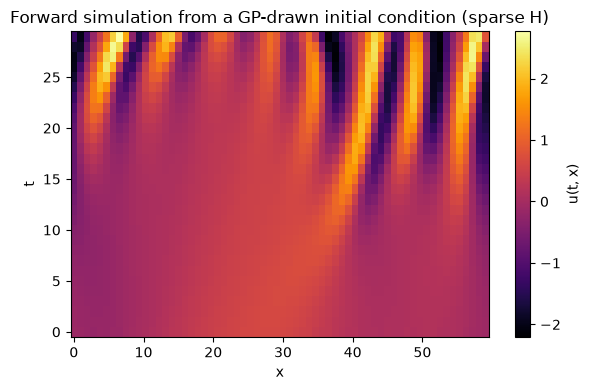

In [6]:
z_demo = jr.normal(jr.PRNGKey(0), (state_dim_ks,))
u0_demo = gp_mean + L_gp @ z_demo

n_steps_demo = 30
predict_times_demo = jnp.arange(n_steps_demo, dtype=jnp.float64)

demo_sim = dsx.simulate(
    build_dynamics_ic(u0_demo), rng_key=jr.PRNGKey(1),
    predict_times=predict_times_demo, n_simulations=1,
)
print("states shape:", demo_sim.states.shape, " observations shape:", demo_sim.observations.shape)
print("any nan:", bool(jnp.any(jnp.isnan(demo_sim.states))))

fig, ax = plt.subplots(figsize=(6, 4))
mesh = ax.pcolormesh(x_grid, predict_times_demo, demo_sim.states[0], shading="auto", cmap="inferno")
fig.colorbar(mesh, ax=ax, label="u(t, x)")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Forward simulation from a GP-drawn initial condition (sparse H)")
plt.tight_layout()
plt.show()


## Inferring the initial condition

Pick a different GP draw as ground truth, generate a short window of noisy sparse
observations, and recover $u_0$ with NUTS running through the EnKF-marginalized likelihood.
`EnKFConfig.crn_seed` is fixed (required for `jax.grad` through the filter to be
well-defined), and NUTS is initialized at the closed-form GP-regression posterior mean given
the $t=0$ observation alone -- exact, since both the prior and the observation model are
linear-Gaussian:

$$
\mu_{\text{post}} = \mu + K H^\top (H K H^\top + R)^{-1}(y_0 - H\mu).
$$

`max_tree_depth` is capped at 6 (the default of 10 turns out to be needlessly expensive
here -- see the full notebook for that comparison).


In [7]:
n_steps_infer = 6
predict_times_infer = jnp.arange(n_steps_infer, dtype=jnp.float64)

true_z = jr.normal(jr.PRNGKey(42), (state_dim_ks,))
true_u0 = gp_mean + L_gp @ true_z

synthetic = dsx.simulate(
    build_dynamics_ic(true_u0), rng_key=jr.PRNGKey(7),
    predict_times=predict_times_infer, n_simulations=1,
)
obs_values_infer = synthetic.observations[0]

# closed-form GP-regression warm start from the t=0 observation alone
H_dense = interp.as_matrix()  # GridInterpolator exposes the same H densely, for this linear algebra
y0 = obs_values_infer[0]
K_obs_obs = H_dense @ K_gp @ H_dense.T + observation_model.R
K_x_obs = K_gp @ H_dense.T
u0_warm_start = gp_mean + K_x_obs @ jnp.linalg.solve(K_obs_obs, y0 - H_dense @ gp_mean)
z_warm_start = jnp.linalg.solve(L_gp, u0_warm_start - gp_mean)
print("||warm_start_u0 - true_u0||:", float(jnp.linalg.norm(u0_warm_start - true_u0)))


||warm_start_u0 - true_u0||: 0.09152363621851407


In [8]:
def ks_ic_model(obs_times=None, obs_values=None):
    z = numpyro.sample("z", dist.Normal(jnp.zeros(state_dim_ks), 1.0).to_event(1))
    u0 = gp_mean + L_gp @ z
    dynamics_ic = build_dynamics_ic(u0)
    with Filter(filter_config=EnKFConfig(n_particles=32, crn_seed=jr.PRNGKey(0))):
        return dsx.sample("f", dynamics_ic, obs_times=obs_times, obs_values=obs_values)


nuts_kernel = NUTS(
    ks_ic_model,
    init_strategy=init_to_value(values={"z": z_warm_start}),
    step_size=1e-2,
    max_tree_depth=6,
)
mcmc = MCMC(nuts_kernel, num_warmup=150, num_samples=150)
mcmc.run(jr.PRNGKey(1), obs_times=predict_times_infer, obs_values=obs_values_infer)

posterior_z = mcmc.get_samples()["z"]
posterior_u0 = gp_mean[None, :] + posterior_z @ L_gp.T
posterior_u0_mean = jnp.mean(posterior_u0, axis=0)
posterior_u0_std = jnp.std(posterior_u0, axis=0)

print("||posterior mean - true_u0||:", float(jnp.linalg.norm(posterior_u0_mean - true_u0)))
print("mean posterior std across grid points:", float(jnp.mean(posterior_u0_std)))


sample: 100%|██████████| 300/300 [00:37<00:00,  8.01it/s, 63 steps of size 2.50e-02. acc. prob=0.93]

||posterior mean - true_u0||: 0.07786563009288042
mean posterior std across grid points: 0.006649992493998666


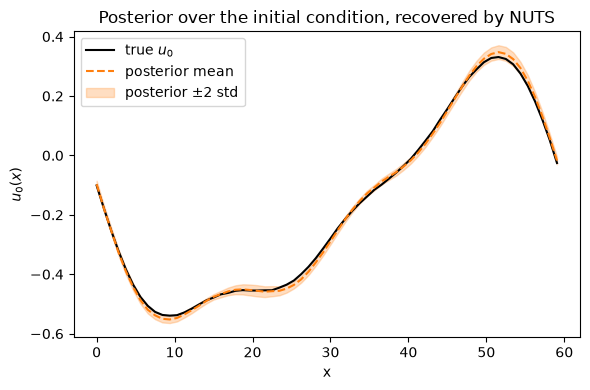

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_grid, true_u0, color="black", label="true $u_0$")
ax.plot(x_grid, posterior_u0_mean, color="tab:orange", linestyle="--", label="posterior mean")
ax.fill_between(
    x_grid, posterior_u0_mean - 2 * posterior_u0_std, posterior_u0_mean + 2 * posterior_u0_std,
    color="tab:orange", alpha=0.25, label=r"posterior $\pm 2$ std",
)
ax.set_xlabel("x")
ax.set_ylabel("$u_0(x)$")
ax.set_title("Posterior over the initial condition, recovered by NUTS")
ax.legend()
plt.tight_layout()
plt.show()


## What this notebook set up

- A `dynestyx.DynamicalModel` whose observation operator is a real
  `jax.experimental.sparse.BCOO` matrix -- built with `GridInterpolator.as_sparse()`,
  not hand-rolled -- used for both forward simulation (`dsx.simulate`) and filtering
  (`EnKFConfig`, via `dsx.condition`/`dsx.sample`) identically to how a dense `H` would
  be used.
- The initial condition treated as a 64-dimensional Gaussian-process-distributed latent,
  recovered with NUTS running through the EnKF-marginalized likelihood -- initialized at a
  closed-form GP-regression warm start rather than a hand-picked value.

See `pde_inference_setup_exponax_ks.ipynb` for the full derivations, the dense-vs-sparse
comparison, and the additional inference problem ($\lambda$, the equation's nonlinearity
strength) this notebook leaves out.
